# NeqSim Network and Gas-Lift Screening

This notebook supports Chapter 20. It demonstrates two production-optimisation building blocks: multi-well gathering with `NetworkSolver` and gas-lift response screening with `GasLiftCalculator`.


In [1]:
from pathlib import Path
import sys
import subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

FIGURES_DIR = NOTEBOOK_DIR.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

PROJECT_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
    if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
        PROJECT_ROOT = candidate
        break

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
WellSystem = JClass("neqsim.process.equipment.reservoir.WellSystem")
IPRModel = JClass("neqsim.process.equipment.reservoir.WellSystem$IPRModel")
NetworkSolver = JClass("neqsim.process.fielddevelopment.network.NetworkSolver")
SolutionMode = JClass("neqsim.process.fielddevelopment.network.NetworkSolver$SolutionMode")
GasLiftCalculator = JClass("neqsim.process.fielddevelopment.screening.GasLiftCalculator")

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures: {FIGURES_DIR}")


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Figures: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\chapters\ch20_production_optimisation\figures


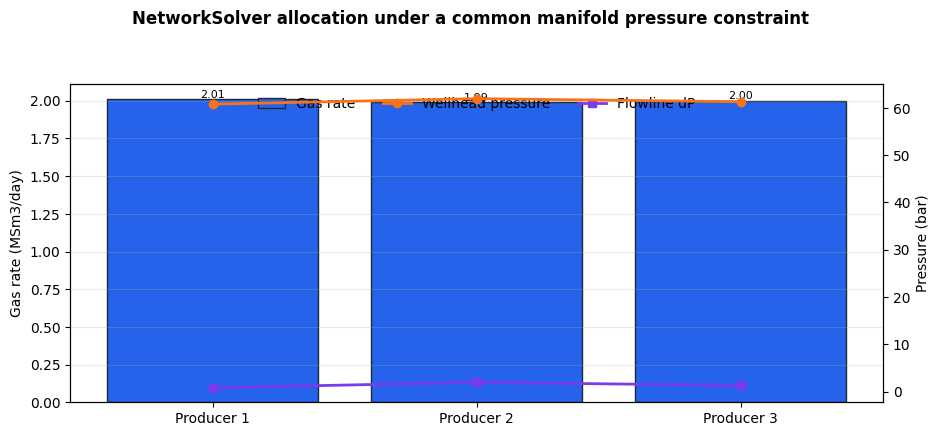

# Network: Teaching gas gathering network

**Manifold Pressure:** 60.0 bara
**Total Rate:** 6.00 MSm3/day
**Converged:** Yes (11 iterations)

| Well | Status | Rate (MSm3/d) | WHP (bara) | ΔP Flowline (bar) |
|------|--------|---------------|------------|-------------------|
| Producer 1 | ON | 2.01 | 60.8 | 0.8 |
| Producer 2 | ON | 1.99 | 62.0 | 2.0 |
| Producer 3 | ON | 2.00 | 61.3 | 1.3 |



In [2]:
base_fluid = SystemSrkEos(273.15 + 70.0, 140.0)
for component, amount in [("methane", 0.88), ("ethane", 0.06), ("propane", 0.04), ("n-butane", 0.02)]:
    base_fluid.addComponent(component, amount)
base_fluid.setMixingRule("classic")

solver = NetworkSolver("Teaching gas gathering network")
solver.setManifoldPressure(60.0, "bara")
solver.setMaxTotalRate(6.0e6, "Sm3/day")
solver.setSolutionMode(SolutionMode.FIXED_MANIFOLD_PRESSURE)
solver.setReferenceFluid(base_fluid)
well_specs = [
    ("Producer 1", 70000.0, 2.5, 12.0),
    ("Producer 2", 45000.0, 6.0, 10.0),
    ("Producer 3", 55000.0, 4.0, 10.0),
]
for name, pi_value, distance_km, diameter_in in well_specs:
    well_fluid = base_fluid.clone()
    well_fluid.setPressure(140.0, "bara")
    stream = Stream(name + " stream", well_fluid)
    stream.setFlowRate(3.0e6, "Sm3/day")
    stream.run()
    well = WellSystem(name, stream)
    well.setIPRModel(IPRModel.PRODUCTION_INDEX)
    well.setProductionIndex(pi_value, "Sm3/day/bar")
    well.setTubingLength(2700.0, "m")
    well.setTubingDiameter(5.0, "in")
    well.setWellheadPressure(70.0, "bara")
    solver.addWell(well, distance_km, diameter_in * 0.0254)
network_result = solver.solve()

names = [spec[0] for spec in well_specs]
rates = [float(network_result.getWellRate(name, "MSm3/day")) for name in names]
whp = [float(network_result.getWellheadPressure(name)) for name in names]
dp = [float(network_result.getFlowlinePressureDrop(name)) for name in names]

fig, ax1 = plt.subplots(figsize=(9.5, 4.4))
x = range(len(names))
bar = ax1.bar(x, rates, color="#2563eb", edgecolor="#1f2937", label="Gas rate")
ax1.set_ylabel("Gas rate (MSm3/day)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(names)
ax1.grid(axis="y", alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(list(x), whp, color="#f97316", marker="o", linewidth=2, label="Wellhead pressure")
ax2.plot(list(x), dp, color="#7c3aed", marker="s", linewidth=2, label="Flowline dP")
ax2.set_ylabel("Pressure (bar)")
for rect, value in zip(bar, rates):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height(), f"{value:.2f}",
             ha="center", va="bottom", fontsize=8)
lines, labels = ax2.get_legend_handles_labels()
ax1.legend([bar] + lines, ["Gas rate"] + labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("NetworkSolver allocation under a common manifold pressure constraint", fontsize=12, weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIGURES_DIR / "ch20_neqsim_network_allocation.png", dpi=160, bbox_inches="tight")
plt.show()

print(network_result.getSummaryTable())


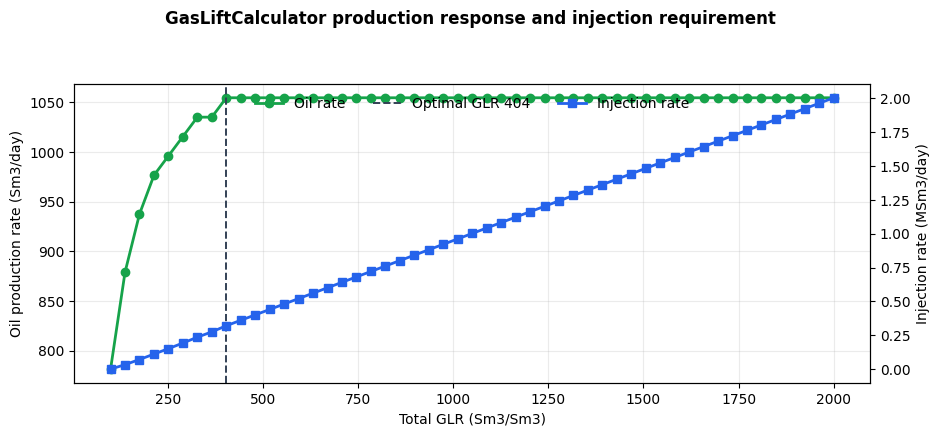

Gas Lift Design Result
Natural flow rate: 374.4 Sm3/day
Optimal GLR: 404.0 Sm3/Sm3
Oil rate at optimal: 1054.7 Sm3/day
Injection rate: 0.321 MSm3/day
Compression power: 10681.4 kW
Lift increase: 181.7%
Valve count: 8
Feasible: true



In [3]:
gas_lift = GasLiftCalculator()
gas_lift.setReservoirPressure(250.0, "bara")
gas_lift.setReservoirTemperature(85.0, "C")
gas_lift.setWellheadPressure(20.0, "bara")
gas_lift.setWellDepth(3000.0, "m")
gas_lift.setProductivityIndex(5.0)
gas_lift.setOilGravity(35.0, "API")
gas_lift.setWaterCut(0.30)
gas_lift.setFormationGOR(100.0)
gas_lift.setInjectionPressure(100.0, "bara")
gas_lift_result = gas_lift.calculate()
curve = [gas_lift_result.performanceCurve.get(i) for i in range(gas_lift_result.performanceCurve.size())]

glr = [float(point.totalGLR) for point in curve]
rate = [float(point.productionRate) for point in curve]
injection = [float(point.injectionRate) for point in curve]

fig, ax1 = plt.subplots(figsize=(9.5, 4.4))
ax1.plot(glr, rate, color="#16a34a", marker="o", linewidth=2, label="Oil rate")
ax1.axvline(float(gas_lift_result.getOptimalGLR()), color="#334155", linestyle="--", linewidth=1.4,
            label=f"Optimal GLR {gas_lift_result.getOptimalGLR():.0f}")
ax1.set_xlabel("Total GLR (Sm3/Sm3)")
ax1.set_ylabel("Oil production rate (Sm3/day)")
ax1.grid(alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(glr, injection, color="#2563eb", marker="s", linewidth=2, label="Injection rate")
ax2.set_ylabel("Injection rate (MSm3/day)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", ncol=3, frameon=False)
fig.suptitle("GasLiftCalculator production response and injection requirement", fontsize=12, weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIGURES_DIR / "ch20_neqsim_gas_lift_response.png", dpi=160, bbox_inches="tight")
plt.show()

print(gas_lift_result)
